## Library import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

In [4]:
from sklearn.preprocessing import MinMaxScaler

### Reading Data

In [5]:
df = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx")
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


### Reading all Excel Sheet.

In [6]:
file_path = "C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx"
fil = pd.ExcelFile(file_path)
print(fil.sheet_names)

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


## Defining Sheets in Variable for merging.

In [7]:
df_demo = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx",sheet_name="Customer_Demographics")

In [8]:
df_trans = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name="Transaction_History")

In [9]:
df_service = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Customer_Service")

In [10]:
df_online = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Online_Activity")

In [11]:
df_churn = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Churn_Status")

### Merging sheets.

In [12]:
df_merged = pd.merge(df_demo, df_trans, on = 'CustomerID')

In [13]:
df_merged = pd.merge(df_merged, df_service, on = 'CustomerID')

In [14]:
df_merged = pd.merge(df_merged, df_online, on = 'CustomerID')

In [15]:
df_finall = pd.merge(df_merged, df_churn, on = 'CustomerID')

In [16]:
df_finall.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


## Data quality checking.

In [17]:
df_finall.isnull().sum()

CustomerID          0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
TransactionID       0
TransactionDate     0
AmountSpent         0
ProductCategory     0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

In [18]:
df_finall.info()

<class 'pandas.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   str           
 3   MaritalStatus     5204 non-null   str           
 4   IncomeLevel       5204 non-null   str           
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[us]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   str           
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[us]
 11  InteractionType   5204 non-null   str           
 12  ResolutionStatus  5204 non-null   str           
 13  LastLoginDate     5204 non-null   datetime64[us]
 14  LoginFrequency    5204 non-null   i

In [19]:
df_finall.shape

(5204, 17)

### Rought estimation of age max min value.

In [20]:
df_finall['Age'].max()  # finding max age

np.int64(69)

In [21]:
df_finall['Age'].min() # finding min age

np.int64(18)

### Histogram for identifying customer age group and frequency.

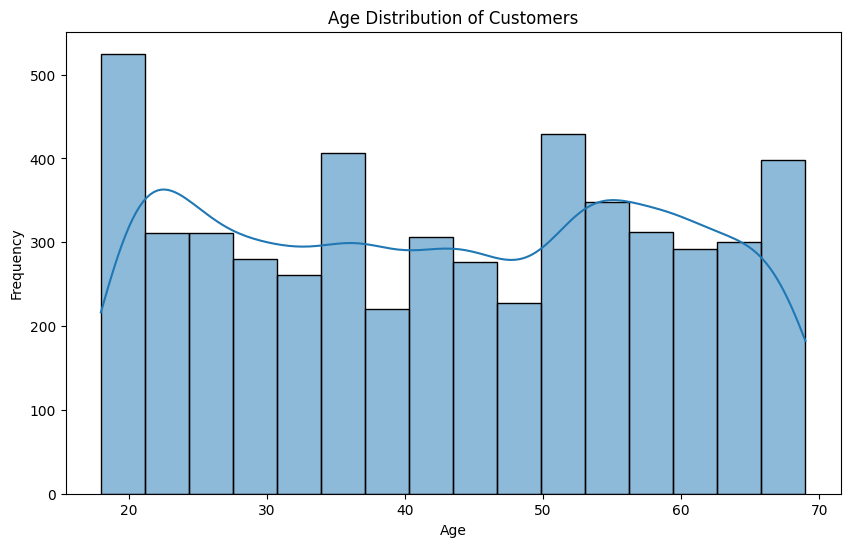

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df_finall, x = 'Age', kde = True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Finding outliers in age and plot it on box plot.

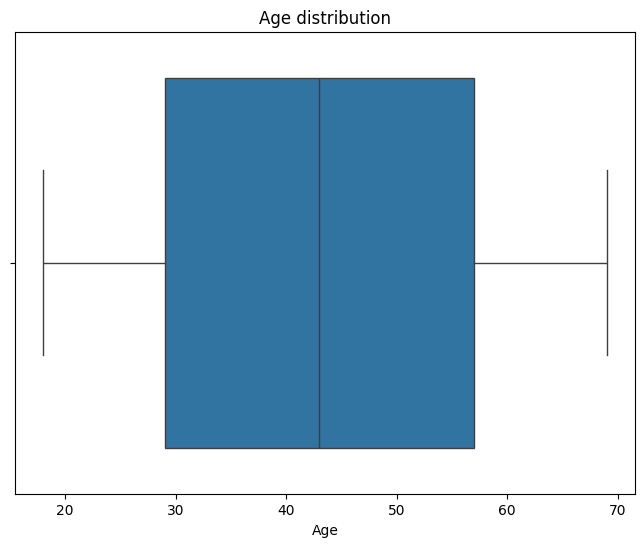

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(df_finall, x = 'Age')
plt.title('Age distribution')
plt.xlabel('Age')                                
plt.show()                          # Age distribution of customers

### Bar charts for categorical data overview.

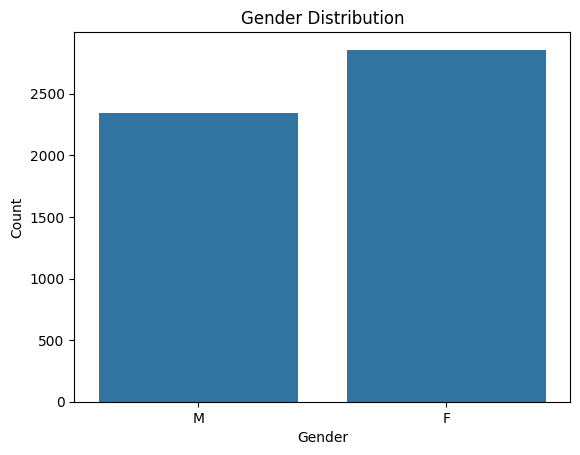

In [ ]:
sns.countplot(df_finall, x = 'Gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()                    # Gender distribution of customers

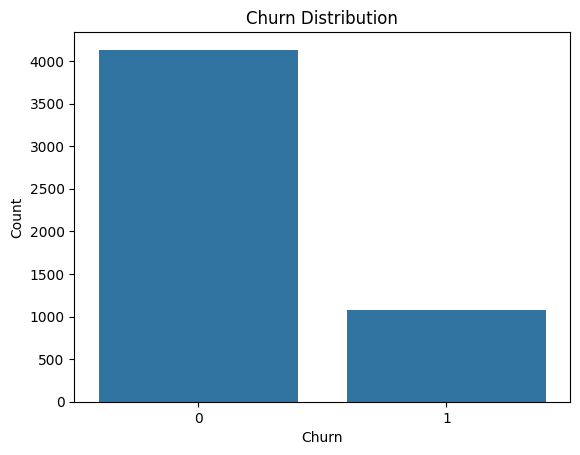

In [ ]:
sns.countplot(df_finall, x = 'ChurnStatus')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()                             # Churn distribution of customers

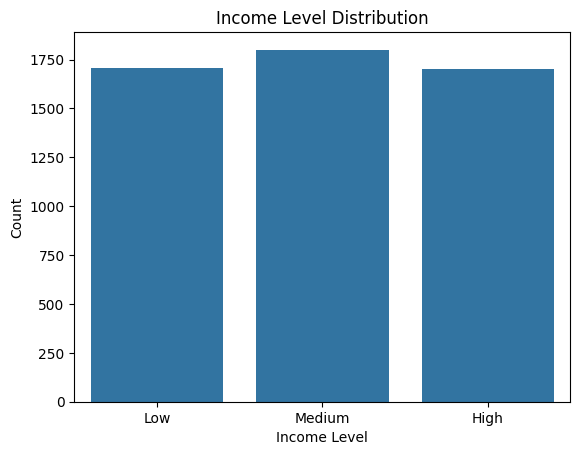

In [ ]:
sns.countplot(df_finall, x = 'IncomeLevel')
plt.title('Income Level Distribution')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()                               # Income level distribution of customers

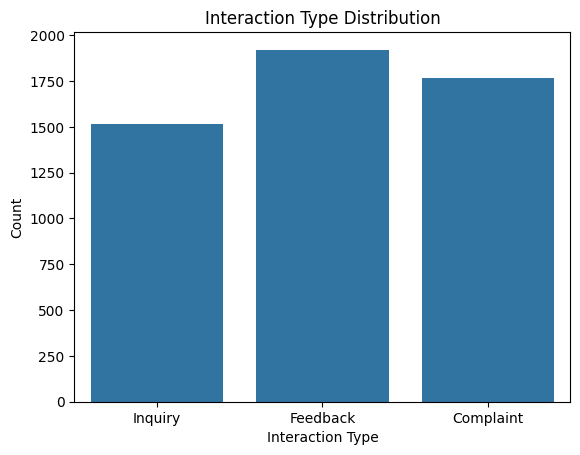

In [ ]:
sns.countplot(df_finall, x = 'InteractionType')
plt.title('Interaction Type Distribution')
plt.xlabel('Interaction Type')
plt.ylabel('Count')
plt.show()                                        # Interaction type distribution of customers


In [89]:
df_finall.head()

,Age,Gender,MaritalStatus,IncomeLevel,TransactionDate,AmountSpent,ProductCategory,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,62,M,Single,Low,2022-03-27,416.50,Electronics,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,65,M,Married,Low,2022-08-08,54.96,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,65,M,Married,Low,2022-07-25,197.50,Electronics,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,65,M,Married,Low,2022-01-25,101.31,Furniture,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,65,M,Married,Low,2022-07-24,397.37,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


## Finding relationship between data by ploting then on scatter plot.

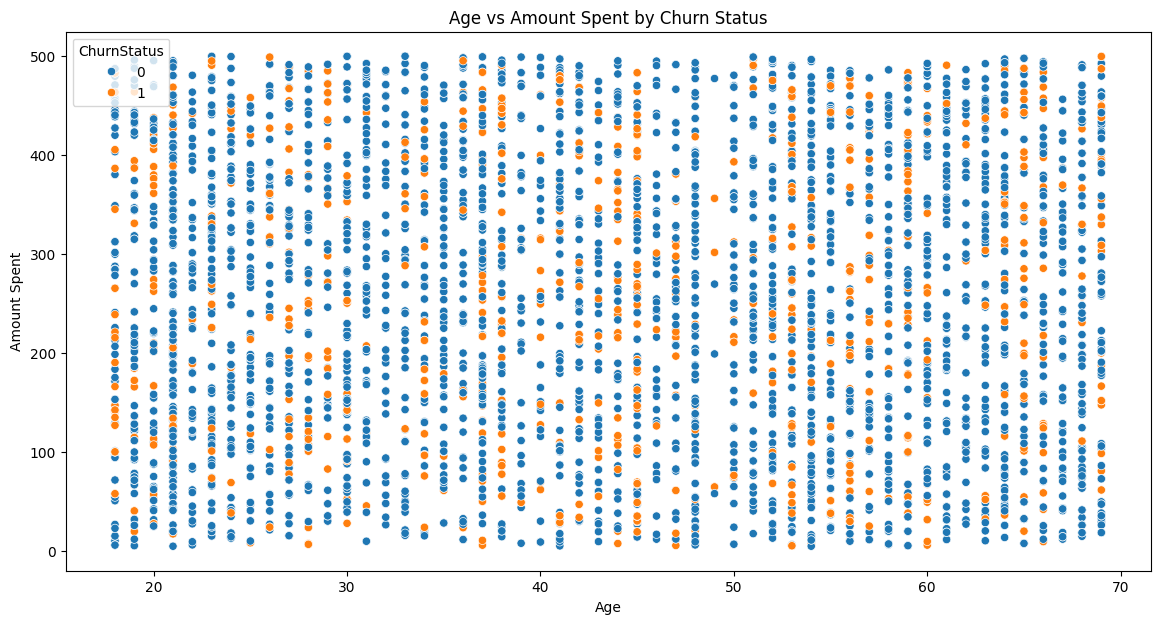

In [88]:
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df_finall, x = 'Age', y = 'AmountSpent', hue = 'ChurnStatus')
plt.title('Age vs Amount Spent by Churn Status')
plt.xlabel('Age')
plt.ylabel('Amount Spent')
plt.show()                             # Age vs Amount Spent by Churn Status

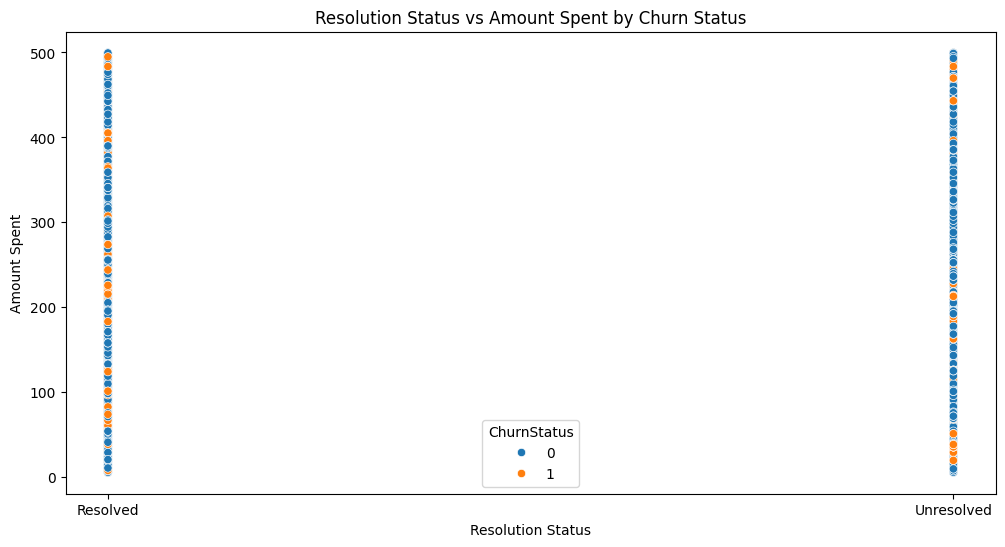

In [91]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_finall, x = 'ResolutionStatus', y = 'AmountSpent', hue = 'ChurnStatus')
plt.title('Resolution Status vs Amount Spent by Churn Status')
plt.xlabel('Resolution Status')
plt.ylabel('Amount Spent')
plt.show()                             # Resolution Status vs Amount Spent by Churn Status

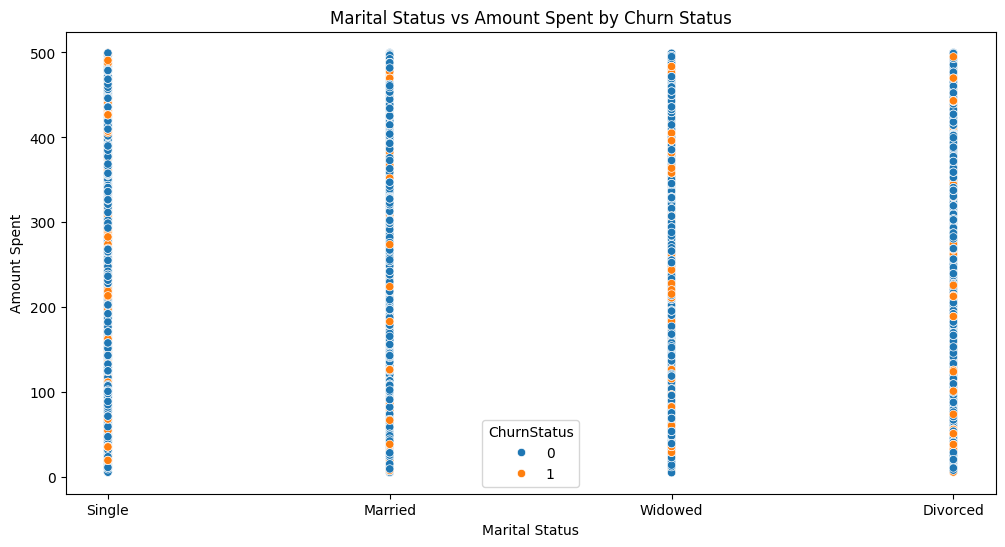

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_finall, x = 'MaritalStatus', y = 'AmountSpent', hue = 'ChurnStatus')
plt.title('Marital Status vs Amount Spent by Churn Status')
plt.xlabel('Marital Status')
plt.ylabel('Amount Spent')
plt.show()                           # Marital Status vs Amount Spent by Churn Status

### Droping unnecessary columns.

In [24]:
drop_columns = ['CustomerID', 'TransactionID', 'InteractionID']
df_finall = df_finall.drop(columns = drop_columns)
print(df_finall.columns)

Index(['Age', 'Gender', 'MaritalStatus', 'IncomeLevel', 'TransactionDate',
       'AmountSpent', 'ProductCategory', 'InteractionDate', 'InteractionType',
       'ResolutionStatus', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage',
       'ChurnStatus'],
      dtype='str')


### Finding correlation between customer churn and its other factor.

In [25]:
# creating variable for storing only numeric value for finding correlation
numeric_df = df_finall.select_dtypes(include = ['number','float', 'int'])

In [26]:
cor_matrix = numeric_df.corr() # finding correlation of numeric column in dataframe.
cor_matrix

,Age,AmountSpent,LoginFrequency,ChurnStatus
Age,1.000000,0.008364,-0.008731,0.036734
AmountSpent,0.008364,1.000000,0.034658,-0.000230
LoginFrequency,-0.008731,0.034658,1.000000,-0.096564
ChurnStatus,0.036734,-0.000230,-0.096564,1.000000


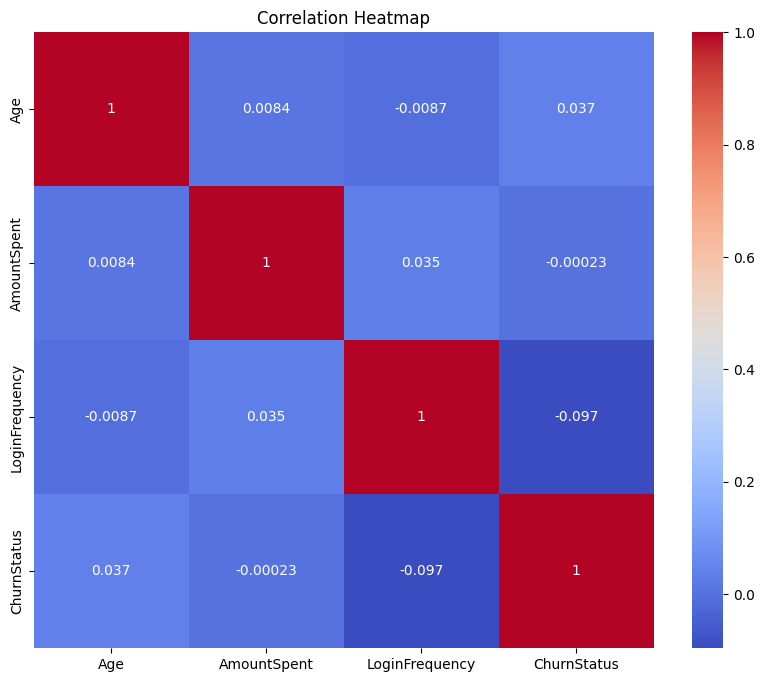

In [27]:
# ploting correlation on heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cor_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
df_finall.head()

,Age,Gender,MaritalStatus,IncomeLevel,TransactionDate,AmountSpent,ProductCategory,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,62,M,Single,Low,2022-03-27,416.50,Electronics,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,65,M,Married,Low,2022-08-08,54.96,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,65,M,Married,Low,2022-07-25,197.50,Electronics,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,65,M,Married,Low,2022-01-25,101.31,Furniture,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,65,M,Married,Low,2022-07-24,397.37,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


### Encoding columns

In [29]:
encoding_columns = ['MaritalStatus','IncomeLevel','Gender','ProductCategory','InteractionType','ResolutionStatus','ServiceUsage'] # creating list of column for encoding them.

In [30]:
df_encoded = pd.get_dummies(df_finall, columns = encoding_columns, drop_first = True,dtype = int)

In [31]:
df_encoded.head()

,Age,TransactionDate,AmountSpent,InteractionDate,LastLoginDate,LoginFrequency,ChurnStatus,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,...,Gender_M,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website
0,62,2022-03-27,416.50,2022-03-31,2023-10-21,34,0,0,1,0,...,1,0,1,0,0,0,1,0,0,0
1,65,2022-08-08,54.96,2022-03-17,2023-12-05,5,1,1,0,0,...,1,1,0,0,0,0,1,0,0,1
2,65,2022-07-25,197.50,2022-03-17,2023-12-05,5,1,1,0,0,...,1,0,1,0,0,0,1,0,0,1
3,65,2022-01-25,101.31,2022-03-17,2023-12-05,5,1,1,0,0,...,1,0,0,1,0,0,1,0,0,1
4,65,2022-07-24,397.37,2022-03-17,2023-12-05,5,1,1,0,0,...,1,1,0,0,0,0,1,0,0,1


In [32]:
df_encoded['TransactionMonth'] = pd.to_datetime(df_encoded['TransactionDate'], errors = 'coerce').dt.month  # Month extracted from TransactionDate column in  anew column.

In [33]:
df_encoded = df_encoded.drop(columns = 'TransactionDate')    # TransactionDate column droped

In [34]:
df_encoded['TransactionMonth']

0        3
1        8
2        7
3        1
4        7
        ..
5199     3
5200     8
5201    10
5202    10
5203    12
Name: TransactionMonth, Length: 5204, dtype: int32

In [35]:
df_encoded['InteractionMonth'] = pd.to_datetime(df_encoded['InteractionDate'], errors = 'coerce').dt.month  # extracting month from interaction date column in a new column.
df_encoded['LastLoginMonth'] = pd.to_datetime(df_encoded['LastLoginDate'], errors = 'coerce').dt.month  # extracting monnth from Last Login date column.

In [36]:
df_encoded = df_encoded.drop(columns = 'InteractionDate')  # InteractionDate column droped
df_encoded = df_encoded.drop(columns = 'LastLoginDate')   # LastLoginDate column droped

In [37]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          5204 non-null   int64  
 1   AmountSpent                  5204 non-null   float64
 2   LoginFrequency               5204 non-null   int64  
 3   ChurnStatus                  5204 non-null   int64  
 4   MaritalStatus_Married        5204 non-null   int64  
 5   MaritalStatus_Single         5204 non-null   int64  
 6   MaritalStatus_Widowed        5204 non-null   int64  
 7   IncomeLevel_Low              5204 non-null   int64  
 8   IncomeLevel_Medium           5204 non-null   int64  
 9   Gender_M                     5204 non-null   int64  
 10  ProductCategory_Clothing     5204 non-null   int64  
 11  ProductCategory_Electronics  5204 non-null   int64  
 12  ProductCategory_Furniture    5204 non-null   int64  
 13  ProductCategory_Groceries    

### Spliting data in X & y variable by train test split.

In [38]:
X = df_encoded.drop('ChurnStatus', axis = 1)  # independent variable

In [39]:
y = df_encoded['ChurnStatus']  # dependent variable

### Checking for variable data shape

In [40]:
X.shape

(5204, 21)

In [41]:
y.shape

(5204,)

### Data definig in train test split and hiding data for test.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # dividing data into train and test set with 80% and 20% respectively.

In [43]:
df_encoded.head()

,Age,AmountSpent,LoginFrequency,ChurnStatus,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,Gender_M,...,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website,TransactionMonth,InteractionMonth,LastLoginMonth
0,62,416.50,34,0,0,1,0,1,0,1,...,0,0,0,1,0,0,0,3,3,10
1,65,54.96,5,1,1,0,0,1,0,1,...,0,0,0,1,0,0,1,8,3,12
2,65,197.50,5,1,1,0,0,1,0,1,...,0,0,0,1,0,0,1,7,3,12
3,65,101.31,5,1,1,0,0,1,0,1,...,1,0,0,1,0,0,1,1,3,12
4,65,397.37,5,1,1,0,0,1,0,1,...,0,0,0,1,0,0,1,7,3,12


### Feature scaling of data.

In [44]:
scaler = MinMaxScaler()

In [45]:
col_scaled = ['Age', 'AmountSpent', 'LoginFrequency', 'LastLoginMonth', 'InteractionMonth', 'TransactionMonth'] # creating list of column for scaling them. 

In [46]:
X_train[col_scaled] = scaler.fit_transform(X_train[col_scaled])  # scaling the column in train set.

In [47]:
X_test[col_scaled] = scaler.transform(X_test[col_scaled])  # scaling the column in test set.

In [48]:
X_train.head()

,Age,AmountSpent,LoginFrequency,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,Gender_M,ProductCategory_Clothing,...,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website,TransactionMonth,InteractionMonth,LastLoginMonth
4667,0.235294,0.430276,0.041667,1,0,0,0,1,0,1,...,0,0,1,0,1,0,1,0.181818,0.000000,0.181818
45,0.411765,0.079026,0.479167,0,0,0,0,0,1,0,...,0,1,0,1,0,0,1,0.000000,0.636364,0.454545
4613,0.156863,0.372280,1.000000,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0.727273,0.727273,0.272727
2664,0.686275,0.161793,0.145833,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0.181818,0.272727,0.727273
4240,0.450980,0.733297,0.166667,1,0,0,1,0,0,1,...,0,0,0,0,0,0,1,1.000000,0.272727,0.363636


In [49]:
X_test.head()

,Age,AmountSpent,LoginFrequency,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,Gender_M,ProductCategory_Clothing,...,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website,TransactionMonth,InteractionMonth,LastLoginMonth
468,0.058824,0.812748,0.750000,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0.454545,0.181818,0.545455
296,0.627451,0.720982,0.375000,0,1,0,1,0,0,1,...,0,0,0,0,1,1,0,0.636364,0.090909,0.545455
4612,1.000000,0.918588,1.000000,0,0,1,0,0,0,0,...,1,0,1,0,0,1,0,0.454545,0.545455,0.909091
4092,1.000000,0.415615,0.625000,1,0,0,1,0,0,0,...,1,0,1,0,0,0,0,1.000000,0.090909,0.636364
3532,0.392157,0.229253,0.895833,0,1,0,0,1,1,0,...,0,1,0,0,1,1,0,0.727273,0.181818,0.000000


### Checking for imbalance data in y train df.

In [50]:
y_train.value_counts()

ChurnStatus
0    3306
1     857
Name: count, dtype: int64

In [51]:
y_test.value_counts()

ChurnStatus
0    826
1    215
Name: count, dtype: int64

In [52]:
from imblearn.over_sampling import SMOTE

In [53]:
smote = SMOTE(random_state = 42)

### Balancing data of x train and y train for accuraacy and recall.

In [54]:
X_train_Smote, y_train_Smote = smote.fit_resample(X_train, y_train)

In [55]:
y_train_Smote.value_counts()

ChurnStatus
0    3306
1    3306
Name: count, dtype: int64

In [57]:
from sklearn.pipeline import Pipeline

In [61]:
from sklearn.model_selection import GridSearchCV

### Pipeline creation and grid search cv for best output.

In [58]:
pipeline = Pipeline([('model', RandomForestClassifier(random_state = 42))]) # creating pipeline for random forest classifier.


In [59]:
param_grid = {
    'model__n_estimators': [50, 100, 160, 200],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}                                                # creating parameter grid for random forest classifier for finding best parameter for model.

In [62]:
grid_search = GridSearchCV(estimator = pipeline, param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1) # creating grid search for finding best parameter for model.


In [63]:
grid_search.fit(X_train_Smote, y_train_Smote) # fitting grid search on train set for finding best parameter for model.

C:\Users\uttam\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [64]:
print("best parameter grid", grid_search.best_params_) # printing best parameter for model.

best parameter grid {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [65]:
best_model = grid_search.best_estimator_ # storing best model in a variable.
y_prediction = best_model.predict(X_test) # predicting the test set using best model.

In [66]:
y_prediction

array([0, 0, 0, ..., 0, 0, 1], shape=(1041,))

In [75]:
accuracy = accuracy_score(y_test, y_prediction) # finding accuracy score of model.
print("Accuracy Score:", accuracy*100)

Accuracy Score: 98.17483189241113


### Finding classification score

In [71]:
classification_score = classification_report(y_test, y_prediction) # finding accuracy score of model.
print("Classification Report:\n", classification_score)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       826
           1       0.98      0.93      0.95       215

    accuracy                           0.98      1041
   macro avg       0.98      0.96      0.97      1041
weighted avg       0.98      0.98      0.98      1041



### Confusion matrix and heatmap.

In [68]:
cm = confusion_matrix(y_test, y_prediction) # creating confusion matrix for test set.
print("Confusion Matrix:",cm)

Confusion Matrix: [[822   4]
 [ 15 200]]


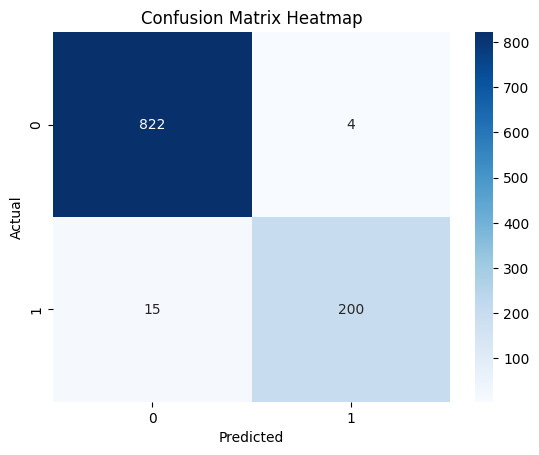

In [69]:
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()